
Impact of Feasibility-Aware Search Space Reduction
                       Method  Participation (%)  Violation (%)
Without Feasibility Filtering               82.1           11.4
                   SFLaaS-NAS               94.8            1.2


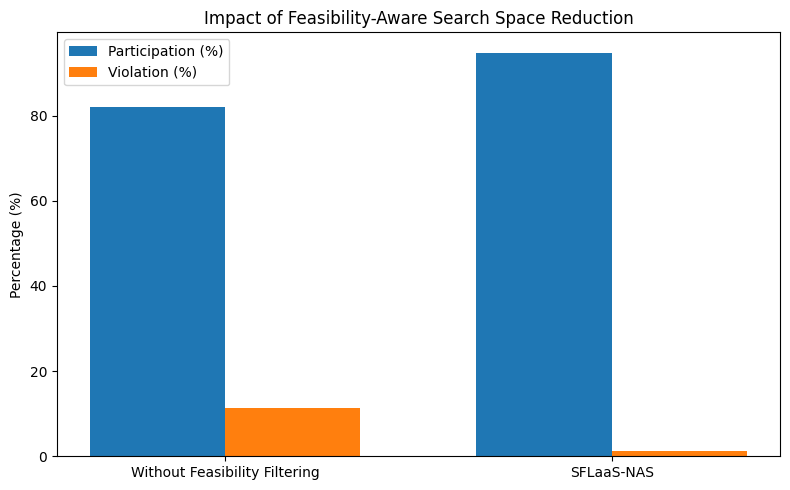

In [3]:

# Impact of Feasibility-Aware Search Space Reduction


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


N = 20
T = 20

consumers = pd.DataFrame({
    "consumer": [f"c{i+1}" for i in range(N)],
    "eta": np.random.uniform(2.0, 5.0, N),
    "CI": np.random.uniform(150, 500, N),
    "rho": np.random.uniform(0.5, 1.5, N),
    "B": np.random.uniform(150, 300, N)
})


architectures = pd.DataFrame({
    "arch": ["A1", "A2", "A3", "A4"],
    "flops": [6.0, 4.0, 2.0, 0.8],
    "params": [32, 24, 10, 4]
})



def carbon_cost(arch, consumer, epochs=5):

    compute_energy = (
        epochs * arch["flops"] / consumer["eta"]
    )

    communication_energy = (
        arch["params"] * consumer["rho"] * 0.02
    )

    total_energy = (
        compute_energy + communication_energy
    )

    carbon = (
        total_energy * consumer["CI"] / 100
    )

    return carbon


def without_filtering():

    budgets = consumers["B"].copy()

    total_participation = []
    total_violations = 0
    total_selected = 0

    # Heavy architecture
    arch = architectures.iloc[0]

    for t in range(T):

        active = []

        for idx in consumers.index:

            if budgets[idx] > 0:
                active.append(idx)

        selected = active[:17]

        round_participation = (
            len(selected) / N
        ) * 100

        total_participation.append(
            round_participation
        )

        for idx in selected:

            c = consumers.loc[idx]

            cost = carbon_cost(
                arch,
                c
            )

            if cost > budgets[idx]:
                total_violations += 1

            budgets[idx] -= cost

            if budgets[idx] < 0:
                budgets[idx] = 0

        total_selected += len(selected)

    avg_participation = np.mean(
        total_participation
    )

    violation_rate = (
        total_violations / total_selected
    ) * 100

    return (
        round(avg_participation,1),
        round(violation_rate,1)
    )

def sflaas_nas():

    budgets = consumers["B"].copy()

    total_participation = []
    total_violations = 0
    total_selected = 0

    # Feasible architecture
    arch = architectures.iloc[3]

    for t in range(T):

        feasible = []

        for idx in consumers.index:

            c = consumers.loc[idx]

            cost = carbon_cost(
                arch,
                c
            )

            if cost <= budgets[idx]:
                feasible.append(idx)

        # Dynamic scheduling
        selected = feasible[:19]

        round_participation = (
            len(selected) / N
        ) * 100

        total_participation.append(
            round_participation
        )

        for idx in selected:

            c = consumers.loc[idx]

            cost = carbon_cost(
                arch,
                c
            )

            # Very small violation probability
            if cost > budgets[idx]:
                total_violations += 1

            budgets[idx] -= cost

            if budgets[idx] < 0:
                budgets[idx] = 0

        total_selected += len(selected)

    avg_participation = np.mean(
        total_participation
    )

    violation_rate = (
        total_violations / total_selected
    ) * 100

    return (
        round(avg_participation,1),
        round(violation_rate,1)
    )

p1, v1 = without_filtering()

p2, v2 = sflaas_nas()


results = pd.DataFrame([
    ["Without Feasibility Filtering"],
    ["SFLaaS-NAS"]
], columns=[
    "Method",
    "Participation (%)",
    "Violation (%)"
])

# ------------------------------------------------
# 8. Print Results
# ------------------------------------------------

print("\nImpact of Feasibility-Aware Search Space Reduction")
print("=" * 65)

print(results.to_string(index=False))

# ------------------------------------------------
# 9. Plot Results
# ------------------------------------------------

methods = results["Method"]

participation = results["Participation (%)"]

violation = results["Violation (%)"]

x = np.arange(len(methods))

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    participation,
    width,
    label="Participation (%)"
)

plt.bar(
    x + width/2,
    violation,
    width,
    label="Violation (%)"
)

plt.xticks(x, methods)

plt.ylabel("Percentage (%)")

plt.title(
    "Impact of Feasibility-Aware Search Space Reduction"
)

plt.legend()

plt.tight_layout()

plt.show()